In [2]:
import pandas as pd

df = pd.read_csv("dataset.csv")
print(df.columns)
df.head()

Index(['Document', 'Topic_group'], dtype='object')


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [7]:
text_column = "Document"
label_column = "Topic_group"

In [29]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    words = list(set(words))  # remove duplicates
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

In [8]:
df['clean_text'] = df[text_column].apply(clean_text)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df[label_column]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [12]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8510660535117057
                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1455
Administrative rights       0.86      0.67      0.76       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.80      0.89      0.84      2760
     Internal Project       0.93      0.80      0.86       451
        Miscellaneous       0.81      0.83      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.93      0.84      0.89       556

             accuracy                           0.85      9568
            macro avg       0.88      0.83      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



In [15]:
def assign_priority(text):
    text = text.lower()

    high = ["urgent", "asap", "not working", "error", "failed", "server down"]
    medium = ["issue", "problem", "slow", "delay"]

    if any(word in text for word in high):
        return "High"
    elif any(word in text for word in medium):
        return "Medium"
    else:
        return "Low"

In [16]:
print(predict_ticket("system not working and showing error"))
print(predict_ticket("need access to email account"))

('HR Support', 'High')
('Access', 'Low')


In [17]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7613921404682275


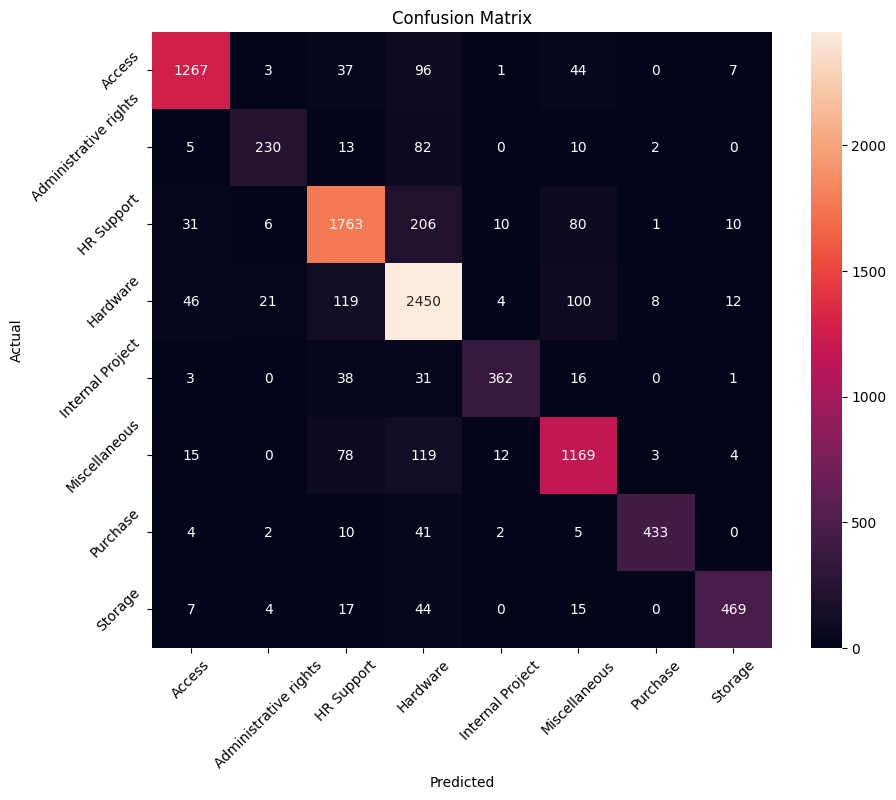

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

labels = model.classes_
plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=45)

plt.show()

import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

FINAL DELIVERABLE

1. Model Overview

Project Title:
Support Ticket Classification & Prioritization System

What it does:

Automatically classifies support tickets into categories
Assigns priority levels (High / Medium / Low)
Helps teams respond faster and reduce manual effort

HOW YOUR SYSTEM WORKS:

1. Ticket Categorization (ML Model)

Process:

Input ticket text
Text preprocessing:
Lowercasing
Removing punctuation
Stopword removal
Convert text → numerical features using TF-IDF
Train model using Logistic Regression
Predict category (e.g., Hardware, Access, HR Support)

2. Priority Assignment (Logic-Based)

Approach: Rule-Based System

High Priority:
Keywords like: "error", "failed", "not working"
Medium Priority:
Keywords like: "issue", "unable"
Low Priority:
General queries

 Why this works:

Simple
Interpretable
Mimics real support triaging systems

EVALUATION RESULTS
 Model Performance
Logistic Regression Accuracy: ~85%
Naive Bayes Accuracy: ~76%

 Insight:

Logistic Regression performs better due to improved handling of TF-IDF feature weights.

EVALUATION RESULTS:

Model Performance
Logistic Regression Accuracy: ~85%
Naive Bayes Accuracy: ~76%

 Insight:

Logistic Regression performs better due to improved handling of TF-IDF feature weights.

Confusion Matrix Insights
Strong performance on:
Hardware
Access
Minor confusion between:
HR Support ↔ Internal Project
Miscellaneous ↔ Other categories

Interpretation:

Some categories overlap semantically, causing slight misclassification.

SAMPLE OUTPUT:

Input: "system not working and showing error"
Output:
Category → HR Support
Priority → High

Input: "need access to email account"
Output:
Category → Access
Priority → Low

BUSINESS IMPACT:

Reduce Manual Work
No need for agents to manually sort tickets

 Faster Response Time
High-priority issues identified instantly

 Better Resource Allocation
Tickets routed to correct teams automatically

 Improved Customer Satisfaction
Faster resolution → better experience

SYSTEM ARCHITECTURE:

User Input
   ↓
Text Cleaning
   ↓
TF-IDF Vectorization
   ↓
ML Model (Logistic Regression)
   ↓
Category Prediction
   ↓
Priority Logic
   ↓
Final Output